In [8]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [8]:
duplicates = df[df.duplicated()]
print(duplicates)

Empty DataFrame
Columns: [price, area, bedrooms, bathrooms, stories, mainroad, guestroom, basement, hotwaterheating, airconditioning, parking, prefarea, furnishingstatus]
Index: []


        price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0    13300000  7420         4          2        3      yes        no       no   
1    12250000  8960         4          4        4      yes        no       no   
2    12250000  9960         3          2        2      yes        no      yes   
3    12215000  7500         4          2        2      yes        no      yes   
4    11410000  7420         4          1        2      yes       yes      yes   
..        ...   ...       ...        ...      ...      ...       ...      ...   
540   1820000  3000         2          1        1      yes        no      yes   
541   1767150  2400         3          1        1       no        no       no   
542   1750000  3620         2          1        1      yes        no       no   
543   1750000  2910         3          1        1       no        no       no   
544   1750000  3850         3          1        2      yes        no       no   

    hotwaterheating aircond

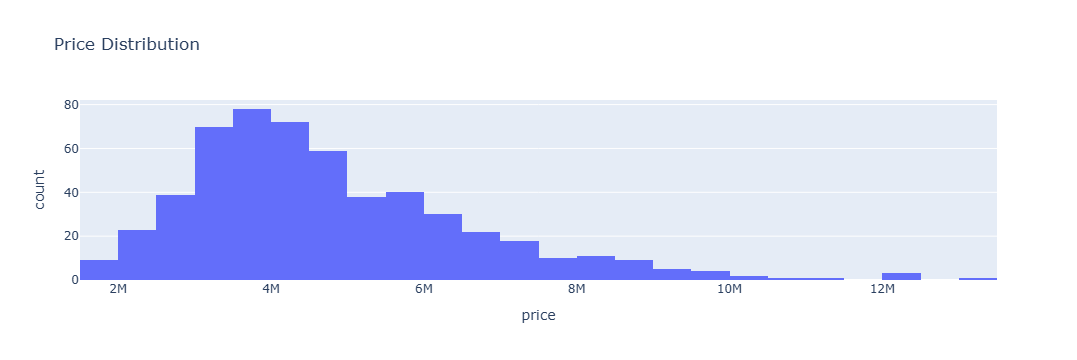

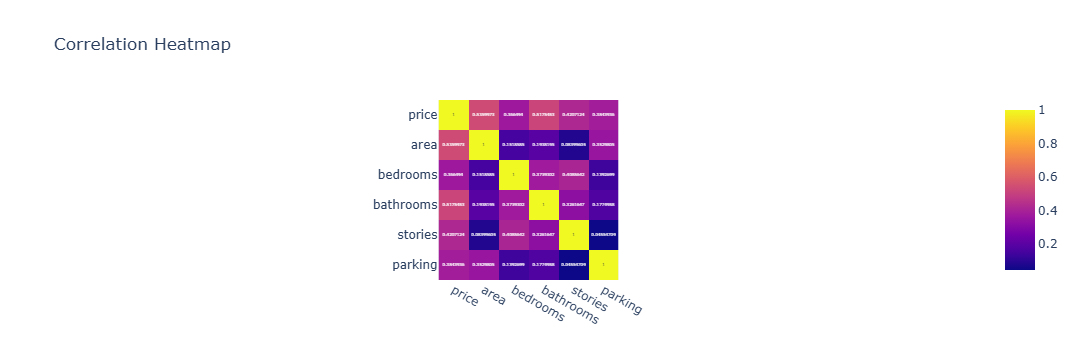

In [18]:
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

df = pd.read_csv("Housing.xls")
print(df)
fig = px.histogram(df, x='price',title='Price Distribution')
fig.show()

corr = df.corr(numeric_only=True)
fig = px.imshow(
    corr,
    text_auto=True,
    title="Correlation Heatmap" )
fig.show()

#encoding:
df = pd.get_dummies(df,drop_first=True)

x = df.drop('price',axis=1)
y = df['price']

x_train,x_test,y_train,y_test =train_test_split(x,y,test_size=0.2,random_state=42)

model = LinearRegression()
model.fit(
    x_train,y_train)

In [20]:
y_pred = model.predict(x_test)

In [21]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    y_test,
    y_pred
)

#RMSE
import numpy as np

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)


#R² Score
r2 = r2_score(
    y_test,
    y_pred
)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 970043.4039201635
RMSE: 1324506.9600914384
R²: 0.6529242642153186


In [23]:
coef_df = pd.DataFrame({
    "Feature": x.columns,
    "Coefficient": model.coef_
})

coef_df.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
2,bathrooms,1.094445e+06
9,airconditioning_yes,7.914267e+05
8,hotwaterheating_yes,6.846499e+05
10,prefarea_yes,6.298906e+05
3,stories,4.074766e+05
7,basement_yes,3.902512e+05
5,mainroad_yes,3.679199e+05
6,guestroom_yes,2.316100e+05
4,parking,2.248419e+05
1,bedrooms,7.677870e+04


In [24]:
new_house = pd.DataFrame({
    'area':[5000],
    'bedrooms':[4],
    'bathrooms':[3],
    'stories':[2],
    'parking':[2],
    'mainroad_yes':[1],
    'guestroom_yes':[0],
    'basement_yes':[1],
    'hotwaterheating_yes':[0],
    'airconditioning_yes':[1],
    'prefarea_yes':[1],
    'furnishingstatus_semi-furnished':[1],
    'furnishingstatus_unfurnished':[0]
})

price = model.predict(new_house)

print("Predicted Price:", round(price[0], 2))

Predicted Price: 8347569.17


In [28]:
#classification:
%pip install matplotlib
import matplotlib.pyplot as plt

Note: you may need to restart the kernel to use updated packages.
